In [24]:
import os
import torch
import warnings
import chunking as C
from tqdm import tqdm
from pathlib import Path
from torch import nn, optim
from resnet20 import resnet20
import torch.nn.functional as F
import json, random, numpy as np
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR100
from transformer_vae import TVAE, vae_loss
from cifar_eval_data import load_cifar_eval
from torch.utils.data import DataLoader, Dataset
from constants import SEED, device, TOKENS_PER_SEQ, IMG_PATH, ZOO_PATH
from reconstruction import interp_to_state_dict, eval_state_dict, reconstruct_model, evaluate_grouped, evaluate_reconstruction
from dataset import ResZoo, summon_res_zoo
warnings.filterwarnings("ignore")

In [25]:
BETA = 3e-6
tvae_model = TVAE()
tvae_model.load_state_dict(torch.load(f'./res_models/tvae_r1_beta{BETA}.pt', weights_only=True)['state_dict'])
tvae_model = tvae_model.to(device)

## Merge two unseen experts during training

In [26]:
(train_dataset_cifar, test_dataset_cifar, full_test_loader, zoo_train_feed, zoo_test_feed) = load_cifar_eval('./res_data/')

FIRST_EXPERT_ID = 3
SECOND_EXPERT_ID = 4
FIRST_MODEL_ID = 'split3_seed1246_ep40'
SECOND_MODEL_ID = 'split4_seed1246_ep40'

'''separate datasets, one per expert'''
ds_one = ResZoo(root_dir=ZOO_PATH, model_ids=[FIRST_MODEL_ID])
ds_two = ResZoo(root_dir=ZOO_PATH, model_ids=[SECOND_MODEL_ID])
loader_one = DataLoader(ds_one, batch_size=64, shuffle=False)
loader_two = DataLoader(ds_two, batch_size=64, shuffle=False)

ck1 = torch.load('res_models/expert3_seed1246/ep040.pt', map_location='cpu')
ck2 = torch.load('res_models/expert4_seed1246/ep040.pt', map_location='cpu')

'''backbone as the reconstruction target, its head works across all 100 classes.
using an expert's head would cap the merge at ~20% by construction'''
ck_bb = torch.load('res_models/backbone_a.pt', map_location='cpu')

'''recalibrate over both experts' classes, the merged model should span both'''
recal_idx = zoo_train_feed[FIRST_EXPERT_ID] + zoo_train_feed[SECOND_EXPERT_ID]
recal_subset = torch.utils.data.Subset(train_dataset_cifar, recal_idx)
recal_loader = DataLoader(recal_subset, batch_size=128, shuffle=True, num_workers=2)

'''sanity check, the two manifests must line up for chunkwise interpolation'''
assert ds_one.meta_list[0].n_chunks_total == ds_two.meta_list[0].n_chunks_total
assert len(ds_one) == len(ds_two)

In [27]:
@torch.no_grad()
def merge_two(model, loader_a, loader_b, lam):
    '''latent space merge: z = (1-lam)*z_a + lam*z_b, decoded chunk by chunk. lam=0 gives expert a, lam=1 gives expert b'''
    model.eval()
    outs = []
    for batch_a, batch_b in zip(loader_a, loader_b):
        depth = batch_a['depth'].to(device, non_blocking=True)
        stage = batch_a['stage'].to(device, non_blocking=True)

        '''use mu, not a sample, so the merge is deterministic'''
        mu_a, _ = model.encode(batch_a['chunks'].to(device), depth, stage)
        mu_b, _ = model.encode(batch_b['chunks'].to(device), depth, stage)

        z = (1 - lam) * mu_a + lam * mu_b
        outs.append(model.decode(z, depth, stage).cpu())

    return torch.concat(outs, dim=0)


def merge_weight_space(sd_a, sd_b, keys, lam):
    '''baseline: plain linear interpolation on the raw weights,
    same keys the vae handles so the comparison is like for like'''
    out = {k: v.clone() for k, v in sd_a.items()}
    for k in keys:
        out[k] = (1 - lam) * sd_a[k].float() + lam * sd_b[k].float()
    return out
    

In [28]:
lambdas = torch.linspace(0.0, 1.0, 11)

In [29]:
'''keys the vae actually reconstructs, so weight space merges the same 19 tensors'''
MERGE_KEYS = [lm.key for lm in ds_one.meta_list[0].layers]

lambdas = torch.linspace(0.0, 1.0, 11)
rows = []

for lam in tqdm(lambdas):
    lam = lam.item()

    '''latent space, decoded onto the backbone so the head spans all 100 classes'''
    out = merge_two(tvae_model, loader_one, loader_two, lam)
    sd_lat = interp_to_state_dict(out, ds_one, ck_bb['state_dict'])
    own3_l, _, all_l = eval_state_dict(sd_lat, FIRST_EXPERT_ID, recal_loader, full_test_loader)
    own4_l, _, _     = eval_state_dict(sd_lat, SECOND_EXPERT_ID, recal_loader, full_test_loader)

    '''weight space baseline, same lam, same recalibration'''
    sd_w = merge_weight_space(ck1['state_dict'], ck2['state_dict'], MERGE_KEYS, lam)
    for k, v in ck_bb['state_dict'].items():
        if k not in MERGE_KEYS:
            sd_w[k] = v.clone()
    own3_w, _, all_w = eval_state_dict(sd_w, FIRST_EXPERT_ID, recal_loader, full_test_loader)
    own4_w, _, _     = eval_state_dict(sd_w, SECOND_EXPERT_ID, recal_loader, full_test_loader)

    rows.append((lam, own3_l, own4_l, all_l, own3_w, own4_w, all_w))
    print(f'lam {lam:.2f} | latent e3 {own3_l:6.2f} e4 {own4_l:6.2f} all {all_l:6.2f} '
          f'| weight e3 {own3_w:6.2f} e4 {own4_w:6.2f} all {all_w:6.2f}')

  0%|                                                                                                                                                       | 0/11 [00:00<?, ?it/s]

  9%|█████████████                                                                                                                                  | 1/11 [00:21<03:34, 21.49s/it]

lam 0.00 | latent e3  82.55 e4   8.40 all  26.37 | weight e3  82.75 e4   6.85 all  23.39


 18%|██████████████████████████                                                                                                                     | 2/11 [00:43<03:14, 21.56s/it]

lam 0.10 | latent e3  82.90 e4  21.95 all  32.35 | weight e3  82.80 e4  18.05 all  28.68


...

lam 0.80 | latent e3  33.40 e4  88.00 all  33.71 | weight e3  30.85 e4  88.70 all  31.57


 91%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████             | 10/11 [03:35<00:21, 21.58s/it]

lam 0.90 | latent e3  17.65 e4  88.40 all  27.93 | weight e3  16.05 e4  89.05 all  26.08


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [03:57<00:00, 21.57s/it]

lam 1.00 | latent e3   7.80 e4  88.45 all  23.08 | weight e3   6.10 e4  88.65 all  21.78


## Merge all four experts

In [30]:
@torch.no_grad()
def merge_n(model, loaders, weights=None):
    '''barycentric merge, z = sum(w_i * z_i) with weights summing to 1'''
    model.eval()
    n = len(loaders)
    if weights is None:
        weights = [1.0 / n] * n

    outs = []
    for batches in zip(*loaders):
        depth = batches[0]['depth'].to(device, non_blocking=True)
        stage = batches[0]['stage'].to(device, non_blocking=True)

        z = None
        for w, b in zip(weights, batches):
            mu, _ = model.encode(b['chunks'].to(device), depth, stage)
            z = w * mu if z is None else z + w * mu
        outs.append(model.decode(z, depth, stage).cpu())

    return torch.concat(outs, dim=0)


def merge_weight_space_n(sds, keys, weights=None):
    n = len(sds)
    if weights is None:
        weights = [1.0 / n] * n
    out = {k: v.clone() for k, v in sds[0].items()}
    for k in keys:
        out[k] = sum(w * sd[k].float() for w, sd in zip(weights, sds))
    return out

In [31]:
ALL_IDS = [f'split{i}_seed1246_ep40' for i in range(5)]
ds_all = [ResZoo(root_dir=ZOO_PATH, model_ids=[m]) for m in ALL_IDS]
loaders_all = [DataLoader(d, batch_size=64, shuffle=False) for d in ds_all]
cks_all = [torch.load(f'res_models/expert{i}_seed1246/ep040.pt', map_location='cpu') for i in range(5)]

'''all five together span 100 classes, so recalibrate on everything'''
recal_all = DataLoader(train_dataset_cifar, batch_size=128, shuffle=True, num_workers=2)

out = merge_n(tvae_model, loaders_all)
sd_lat = interp_to_state_dict(out, ds_all[0], ck_bb['state_dict'])

sd_w = merge_weight_space_n([c['state_dict'] for c in cks_all], MERGE_KEYS)
for k, v in ck_bb['state_dict'].items():
    if k not in MERGE_KEYS:
        sd_w[k] = v.clone()

print(f'{"":<10}' + ''.join(f'{f"e{i}":>8}' for i in range(5)) + f'{"all":>9}')
for name, sd in [('latent', sd_lat), ('weight', sd_w)]:
    per = [eval_state_dict(sd, i, recal_all, full_test_loader) for i in range(5)]
    print(f'{name:<10}' + ''.join(f'{p[0]:>8.2f}' for p in per) + f'{per[0][2]:>9.2f}')

                e0      e1      e2      e3      e4      all
latent       66.55   67.85   68.35   66.15   68.15    67.30
weight       65.65   67.35   67.70   67.25   68.75    67.29


## Permutation test: two independent models

The five experts share a backbone, so they never left the same basin and plain averaging
already works on them. The gap above is real but small, and part of it is the autoencoder
smoothing rather than the merge.

These two models were trained from scratch with different seeds. Hidden units carry no fixed
identity, so two independently trained networks end up as arbitrary permutations of each
other. Averaging them element wise adds unrelated filters together and normally collapses to
near chance.

Whether latent merging survives that is the open question.

In [32]:
'''the splits are 50 wide here, evaluate_grouped assumes 20 so we need a range version'''
@torch.no_grad()
def evaluate_range(model, loader, lo, hi):
    model.eval()
    own_c = own_n = oth_c = oth_n = 0
    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        pred = model(images).argmax(1)
        m = (labels >= lo) & (labels < hi)
        own_c += (pred[m] == labels[m]).sum().item();   own_n += m.sum().item()
        oth_c += (pred[~m] == labels[~m]).sum().item(); oth_n += (~m).sum().item()
    return (100.0 * own_c / max(own_n, 1),
            100.0 * oth_c / max(oth_n, 1),
            100.0 * (own_c + oth_c) / (own_n + oth_n))


def eval_state_dict_range(sd, lo, hi, recal_loader, test_loader):
    from reconstruction import recalibrate_bn
    m = resnet20(num_classes=100).to(device)
    m.load_state_dict(sd, strict=True)
    recalibrate_bn(m, recal_loader)
    return evaluate_range(m, test_loader, lo, hi)


def fill_non_merge_keys(sd, sd_a, sd_b, keys, lam):
    '''the vae only covers 19 tensors, the stem conv and every batchnorm gamma and beta
    are outside it. these two models share nothing with the backbone, so those keys are
    interpolated between the parents instead of borrowed'''
    for k, v in sd_a.items():
        if k in keys:
            continue
        if v.dtype.is_floating_point:
            sd[k] = (1 - lam) * sd_a[k].float() + lam * sd_b[k].float()
        else:
            sd[k] = sd_a[k].clone()
    return sd

In [33]:
ds_a = ResZoo(root_dir='./zoo_independent', model_ids=['indep_0'])
ds_b = ResZoo(root_dir='./zoo_independent', model_ids=['indep_1'])
loader_a = DataLoader(ds_a, batch_size=64, shuffle=False)
loader_b = DataLoader(ds_b, batch_size=64, shuffle=False)

cka = torch.load('res_models_independent/indep_0.pt', map_location='cpu')
ckb = torch.load('res_models_independent/indep_1.pt', map_location='cpu')

'''the two models together span all 100 classes, so recalibrate on everything'''
recal_all = DataLoader(train_dataset_cifar, batch_size=128, shuffle=True, num_workers=2)

assert ds_a.meta_list[0].n_chunks_total == ds_b.meta_list[0].n_chunks_total
assert len(ds_a) == len(ds_b)

'''sanity: these should be far apart in weight space, unlike the shared backbone experts'''
k0 = 'layer3.1.conv1.weight'
wa, wb = cka['state_dict'][k0].float(), ckb['state_dict'][k0].float()
print(f'{k0} relative distance: {(wa - wb).norm() / wa.norm():.4f}')

layer3.1.conv1.weight relative distance: 1.4024


In [34]:
rows_ind = []

for lam in tqdm(lambdas):
    lam = lam.item()

    '''latent space, decoded onto parent a then the non vae keys interpolated'''
    out = merge_two(tvae_model, loader_a, loader_b, lam)
    sd_lat = interp_to_state_dict(out, ds_a, cka['state_dict'])
    sd_lat = fill_non_merge_keys(sd_lat, cka['state_dict'], ckb['state_dict'], MERGE_KEYS, lam)
    a_l, _, all_l = eval_state_dict_range(sd_lat, 0, 50, recal_all, full_test_loader)
    b_l, _, _     = eval_state_dict_range(sd_lat, 50, 100, recal_all, full_test_loader)

    '''weight space baseline, this is the one expected to collapse'''
    sd_w = merge_weight_space(cka['state_dict'], ckb['state_dict'], MERGE_KEYS, lam)
    sd_w = fill_non_merge_keys(sd_w, cka['state_dict'], ckb['state_dict'], MERGE_KEYS, lam)
    a_w, _, all_w = eval_state_dict_range(sd_w, 0, 50, recal_all, full_test_loader)
    b_w, _, _     = eval_state_dict_range(sd_w, 50, 100, recal_all, full_test_loader)

    rows_ind.append((lam, a_l, b_l, all_l, a_w, b_w, all_w))
    print(f'lam {lam:.2f} | latent 0-49 {a_l:6.2f} 50-99 {b_l:6.2f} all {all_l:6.2f} '
          f'| weight 0-49 {a_w:6.2f} 50-99 {b_w:6.2f} all {all_w:6.2f}')

  9%|█████████████                                                                                                                                  | 1/11 [00:21<03:37, 21.77s/it]

lam 0.00 | latent 0-49  49.98 50-99   0.00 all  24.99 | weight 0-49  74.92 50-99   0.00 all  37.46


 18%|██████████████████████████                                                                                                                     | 2/11 [00:43<03:15, 21.73s/it]

lam 0.10 | latent 0-49  42.82 50-99   0.00 all  21.41 | weight 0-49  72.44 50-99   0.00 all  36.22


 27%|███████████████████████████████████████                                                                                                        | 3/11 [01:05<02:53, 21.71s/it]

...

lam 0.80 | latent 0-49   0.00 50-99  27.40 all  13.70 | weight 0-49   0.00 50-99  63.44 all  31.76


 91%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████             | 10/11 [03:36<00:21, 21.70s/it]

lam 0.90 | latent 0-49   0.00 50-99  40.96 all  20.59 | weight 0-49   0.00 50-99  73.16 all  36.61


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [03:58<00:00, 21.70s/it]

lam 1.00 | latent 0-49   0.00 50-99  45.62 all  22.92 | weight 0-49   0.00 50-99  75.80 all  37.99


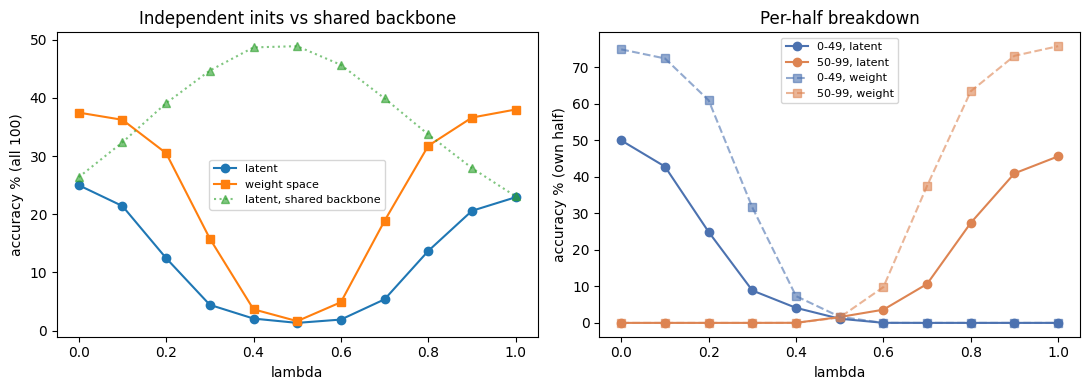

In [35]:
import matplotlib.pyplot as plt

lams = [r[0] for r in rows_ind]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(lams, [r[3] for r in rows_ind], marker='o', label='latent')
axes[0].plot(lams, [r[6] for r in rows_ind], marker='s', label='weight space')
axes[0].plot([r[0] for r in rows], [r[3] for r in rows], marker='^', ls=':', alpha=0.6,
             label='latent, shared backbone')
axes[0].set_xlabel('lambda'); axes[0].set_ylabel('accuracy % (all 100)')
axes[0].set_title('Independent inits vs shared backbone'); axes[0].legend(fontsize=8)

axes[1].plot(lams, [r[1] for r in rows_ind], marker='o', c='#4C72B0', label='0-49, latent')
axes[1].plot(lams, [r[2] for r in rows_ind], marker='o', c='#DD8452', label='50-99, latent')
axes[1].plot(lams, [r[4] for r in rows_ind], marker='s', ls='--', c='#4C72B0', alpha=0.6, label='0-49, weight')
axes[1].plot(lams, [r[5] for r in rows_ind], marker='s', ls='--', c='#DD8452', alpha=0.6, label='50-99, weight')
axes[1].set_xlabel('lambda'); axes[1].set_ylabel('accuracy % (own half)')
axes[1].set_title('Per-half breakdown'); axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(os.path.join(IMG_PATH, 'permutation_merge.png'), dpi=150)
plt.show()

## Permutation test with the retrained autoencoder

Same sweep, same two models, but encoded by the autoencoder that saw three initialisations
instead of one. If the latent curve still has a hole at $\lambda{=}0.5$ while reconstruction
at the endpoints is now healthy, the failure is permutation misalignment rather than an
undertrained encoder.

In [36]:
BETA_V2 = 3e-6
tvae_v2 = TVAE(input_dim=144, model_dim=256, latent_dim=144)
tvae_v2.load_state_dict(torch.load(f'./res_models/tvae_v2_r1_beta{BETA_V2}.pt',
                                   weights_only=True)['state_dict'])
tvae_v2 = tvae_v2.to(device)

rows_v2 = []

for lam in tqdm(lambdas):
    lam = lam.item()

    out = merge_two(tvae_v2, loader_a, loader_b, lam)
    sd_lat = interp_to_state_dict(out, ds_a, cka['state_dict'])
    sd_lat = fill_non_merge_keys(sd_lat, cka['state_dict'], ckb['state_dict'], MERGE_KEYS, lam)
    a_l, _, all_l = eval_state_dict_range(sd_lat, 0, 50, recal_all, full_test_loader)
    b_l, _, _     = eval_state_dict_range(sd_lat, 50, 100, recal_all, full_test_loader)

    rows_v2.append((lam, a_l, b_l, all_l))
    print(f'lam {lam:.2f} | v2 latent 0-49 {a_l:6.2f} 50-99 {b_l:6.2f} all {all_l:6.2f}')

  9%|█████████████                                                                                                                                  | 1/11 [00:10<01:48, 10.83s/it]

lam 0.00 | v2 latent 0-49  72.44 50-99   0.00 all  36.22


 18%|██████████████████████████                                                                                                                     | 2/11 [00:21<01:37, 10.86s/it]

lam 0.10 | v2 latent 0-49  67.98 50-99   0.00 all  33.99


 27%|███████████████████████████████████████                                                                                                        | 3/11 [00:32<01:26, 10.80s/it]

...

lam 0.80 | v2 latent 0-49   0.00 50-99  55.58 all  27.81


 91%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████             | 10/11 [01:48<00:10, 10.85s/it]

lam 0.90 | v2 latent 0-49   0.00 50-99  68.92 all  34.45


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [01:59<00:00, 10.83s/it]

lam 1.00 | v2 latent 0-49   0.00 50-99  72.40 all  36.12


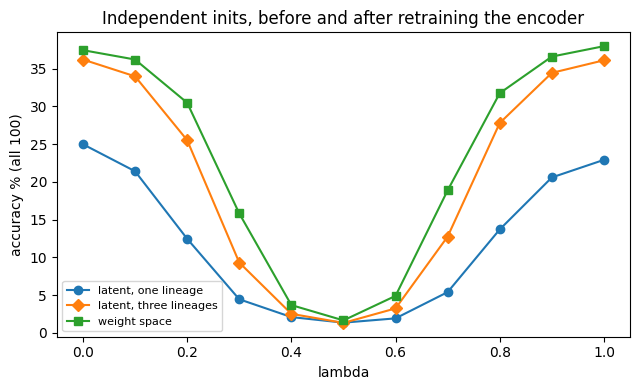

In [37]:
lams = [r[0] for r in rows_v2]
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(lams, [r[3] for r in rows_ind], marker='o', label='latent, one lineage')
ax.plot(lams, [r[3] for r in rows_v2],  marker='D', label='latent, three lineages')
ax.plot(lams, [r[6] for r in rows_ind], marker='s', label='weight space')
ax.set_xlabel('lambda')
ax.set_ylabel('accuracy % (all 100)')
ax.set_title('Independent inits, before and after retraining the encoder')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(IMG_PATH, 'permutation_merge_v2.png'), dpi=150)
plt.show()